In [1]:
%load_ext autoreload
%autoreload 2

In [12]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, score_single_row
from ariel_pred.utils import train_submission_maker
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd

In [44]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [45]:
labels_df = pd.read_csv(Path("../data/raw") / "train.csv")

In [46]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features, transit_locations = features_extractor.extract_features(train_data, return_transit_locations=True)
features.shape, transit_locations.shape

100%|██████████| 1100/1100 [03:27<00:00,  5.31it/s]


((1100, 283), (1100, 4))

In [47]:
df = train_submission_maker(Path("../data/raw/"), predictions=features, sigma=0.000715, multiplier=0.945)
score(
    solution=labels_df,
    submission=df,
    row_id_column_name='planet_id',
    naive_mean=train_labels.mean(),
    naive_sigma=train_labels.std()
)

0.3359057273038888

In [49]:
smoother = SGSmoothing(window_size=20, poly_order=3)
smoothed_features = np.array([smoother.smooth(row) for row in features])
df = train_submission_maker(Path("../data/raw/"), predictions=smoothed_features, sigma=0.000715, multiplier=0.945)
score(
    solution=labels_df,
    submission=df,
    row_id_column_name='planet_id',
    naive_mean=train_labels.mean(),
    naive_sigma=train_labels.std()
)

0.3361242980716222

In [84]:
smoother = SGSmoothing(window_size=150, poly_order=3)
smoothed_features = np.array([smoother.smooth(row) for row in features])
def cost_function(params):
    sigma, multiplier = params
    df = train_submission_maker(Path("../data/raw/"), predictions=smoothed_features, sigma=sigma, multiplier=multiplier)
    return -score(
        solution=labels_df,
        submission=df,
        row_id_column_name='planet_id',
        naive_mean=train_labels.mean(),
        naive_sigma=train_labels.std()
    )
    
initial_guess = [.000715, 0.945]
result = minimize(cost_function, initial_guess, method='Nelder-Mead', bounds=[(0.00001, 0.01), (0.75, 1.25)])
optimal_sigma, optimal_multiplier = result.x
optimal_sigma, optimal_multiplier, -result.fun

(np.float64(0.0007358457170724871),
 np.float64(0.9454861643314361),
 np.float64(0.3323101362339594))

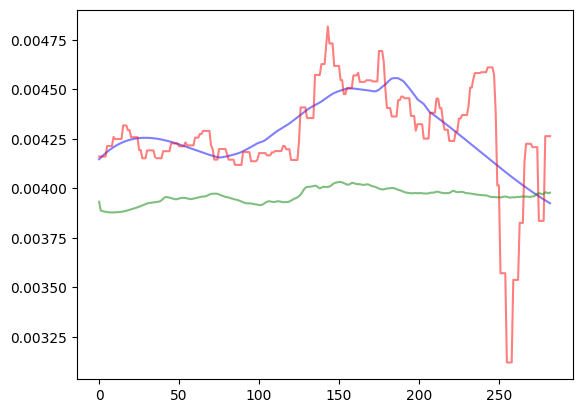

In [85]:
random_index = random.randint(0 ,smoothed_features.shape[0]-1)
plt.plot(smoothed_features[random_index], color='blue', alpha=0.5)
plt.plot(features[random_index], color='red', alpha=0.5)
plt.plot(train_labels[random_index], color='green', alpha=0.5)
plt.show()

In [19]:
df.to_csv("./data.csv")